In [2]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
titanic_file_path = tf.keras.utils.get_file("train.csv", 
"https://storage.googleapis.com/tf-datasets/titanic/train.csv") 
df = pd.read_csv(titanic_file_path) 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.rename(columns = {"survived":"target"},inplace=True) 
np.random.seed(5)  
train, val, test = np.split(df.sample(frac=1), [int(0.8*len(df)), 
int(0.9*len(df))])  
train 

C:\Users\GFLAB\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
126,127,0,3,"McMahon, Mr. Martin",male,NaN,0,0,370372,7.7500,NaN,Q
354,355,0,3,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C
590,591,0,3,"Rintamaki, Mr. Matti",male,35.0,0,0,STON/O 2. 3101273,7.1250,NaN,S
509,510,1,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
769,770,0,3,"Gronnestad, Mr. Daniel Danielsen",male,32.0,0,0,8471,8.3625,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
465,466,0,3,"Goncalves, Mr. Manuel Estanslas",male,38.0,0,0,SOTON/O.Q. 3101306,7.0500,NaN,S
167,168,0,3,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",female,45.0,1,4,347088,27.9000,NaN,S
407,408,1,2,"Richards, Master. William Rowe",male,3.0,1,1,29106,18.7500,NaN,S
616,617,0,3,"Danbom, Mr. Ernst Gilbert",male,34.0,1,1,347080,14.4000,NaN,S


In [5]:
def df_to_dataset(dataframe, shuffle=True, batch_size=32): 
    df = dataframe.copy() 
    labels = df.pop('Survived') 
    df = df.select_dtypes(include=[np.number])
    df = {key: value.values[:,tf.newaxis] for key, value in df.items()} 
    ds = tf.data.Dataset.from_tensor_slices((df,labels.values)) 
    if shuffle: 
        ds = ds.shuffle(buffer_size=len(dataframe)) 
    ds = ds.batch(batch_size) 
    ds = ds.prefetch(batch_size) 
    return ds

In [6]:
batch_size = 10 
train_ds = df_to_dataset(train, batch_size=batch_size) 
val_ds = df_to_dataset(val, batch_size=batch_size) 
test_ds = df_to_dataset(test, batch_size=batch_size) 

In [7]:
def get_normalization_layer(name, dataset): 
    normalizer = tf.keras.layers.Normalization(axis=None) 
    feature_ds = dataset.map(lambda x, y: x[name]) 
    normalizer.adapt(feature_ds) 
    return normalizer 
def get_category_encoding_layer(name, dataset, dtype, max_tokens=None):
    if dtype == 'string': 
        index = tf.keras.layers.StringLookup(max_tokens=max_tokens)
    else: 
        index = tf.keras.layers.IntegerLookup(max_tokens=max_tokens)  
    feature_ds = dataset.map(lambda x, y: x[name]) 
    index.adapt(feature_ds) 
    encoder = tf.keras.layers.CategoryEncoding(num_tokens=index.vocabulary_size()) 
    return lambda feature: encoder(index(feature)) 

In [8]:
numerical_cols = ["Age","Fare"] 
numerical_categorical_cols = ["SibSp","Parch"] 
categorical_cols = [] 
 
all_inputs = [] 
encoded_features = [] 

for header in numerical_cols: 
    numeric_col = tf.keras.Input(shape=(1,), name=header) 
    normalization_layer = get_normalization_layer("Age", train_ds) 
    encoded_numeric_col = normalization_layer(numeric_col) 
    all_inputs.append(numeric_col) 
    encoded_features.append(encoded_numeric_col) 
 
for header in numerical_categorical_cols: 
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='int64') 
    encoding_layer = get_category_encoding_layer(name=header,dataset=train_ds,dtype='int64')
    encoded_categorical_col = encoding_layer(categorical_col) 
    all_inputs.append(categorical_col) 
    encoded_features.append(encoded_categorical_col) 
 
for header in categorical_cols: 
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='string') 
    encoding_layer = get_category_encoding_layer(name=header,dataset=train_ds,dtype='string',max_tokens=5)
    encoded_categorical_col = encoding_layer(categorical_col) 
    all_inputs.append(categorical_col) 
    encoded_features.append(encoded_categorical_col)

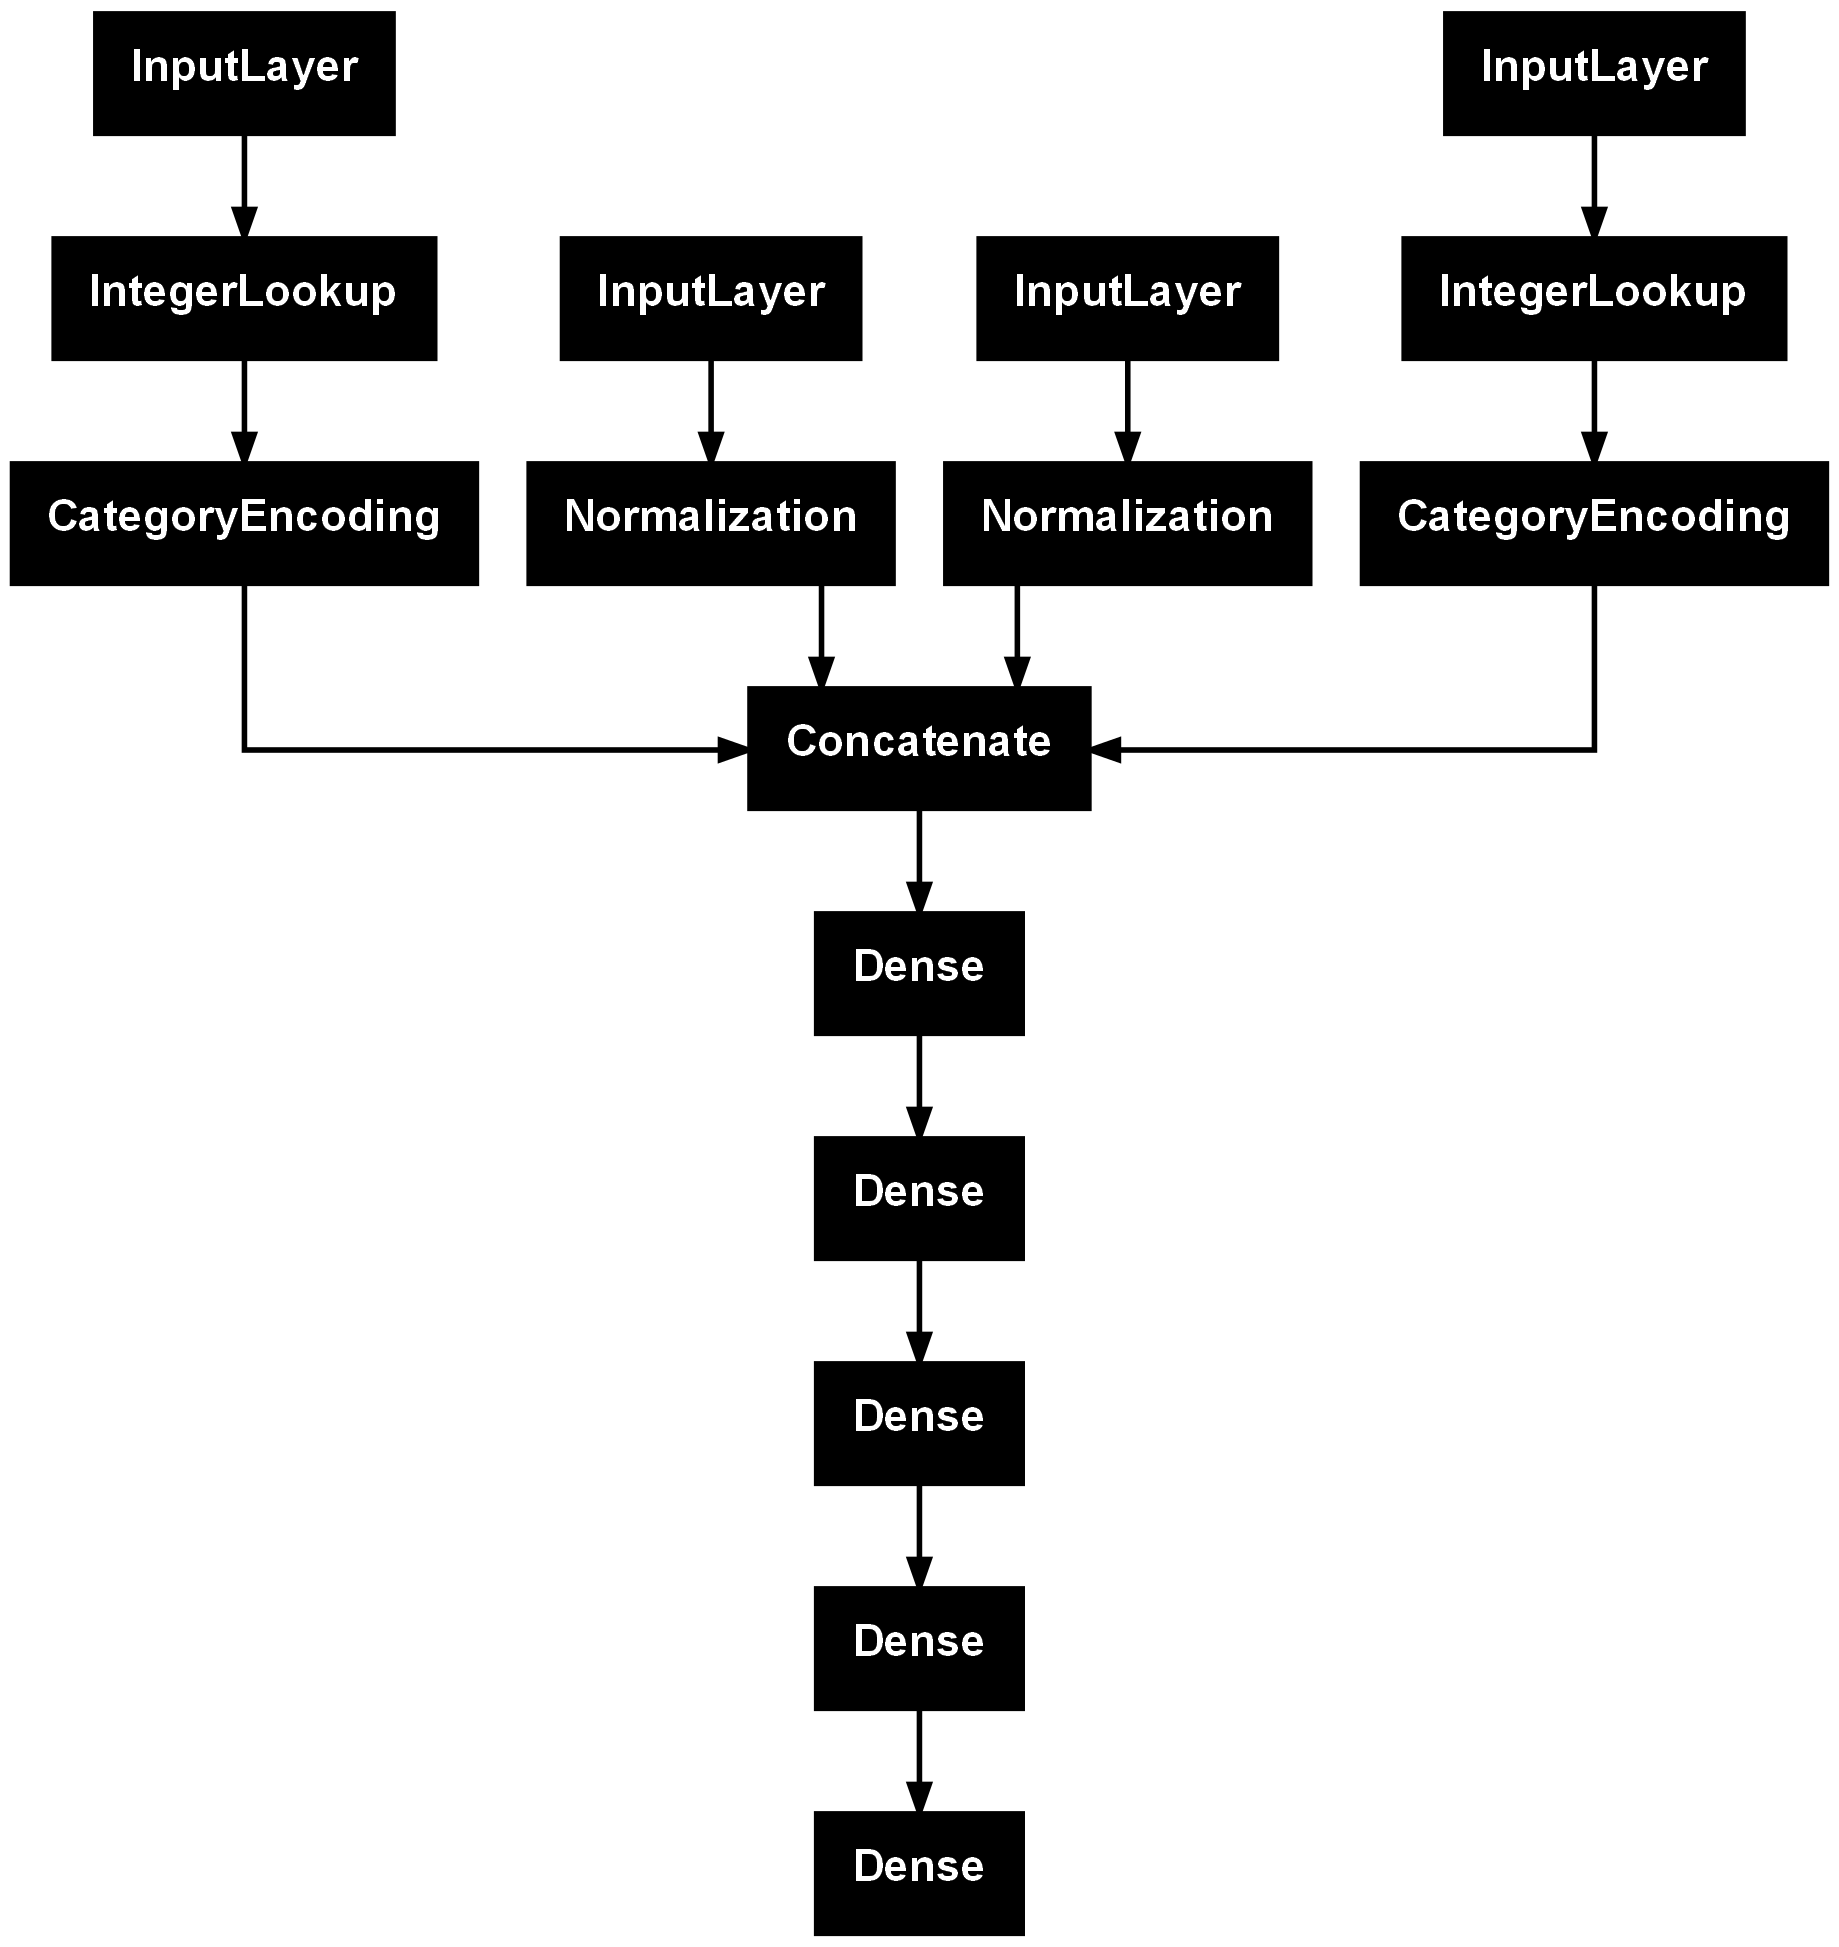

In [9]:
x = tf.keras.layers.concatenate(encoded_features) 
x = tf.keras.layers.Dense(32, activation="relu")(x) 
x = tf.keras.layers.Dense(8, activation="relu")(x) 
x = tf.keras.layers.Dense(4, activation="relu")(x) 
x = tf.keras.layers.Dense(2, activation="relu")(x) 
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x) 
model = tf.keras.Model(all_inputs,outputs) 
model.compile( 
    optimizer='adam', 
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), 
    metrics=["accuracy"] 
) 
tf.keras.utils.plot_model(model) 

In [10]:
history = model.fit(train_ds,validation_data=val_ds,epochs=50)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.6124 - loss: 0.6908 - val_accuracy: 0.6404 - val_loss: 0.6870
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6124 - loss: 0.6868 - val_accuracy: 0.6404 - val_loss: 0.6826
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6124 - loss: 0.6835 - val_accuracy: 0.6404 - val_loss: 0.6787
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6124 - loss: 0.6807 - val_accuracy: 0.6404 - val_loss: 0.6753
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6124 - loss: 0.6783 - val_accuracy: 0.6404 - val_loss: 0.6721
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6124 - loss: 0.6763 - val_accuracy: 0.6404 - val_loss: 0.6698
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6124 - loss: 0.6749 - val_accuracy: 0.6404 - val_loss: 0.6678
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6124 - loss: 0.6735 - val_accuracy: 0.6404 - val_los

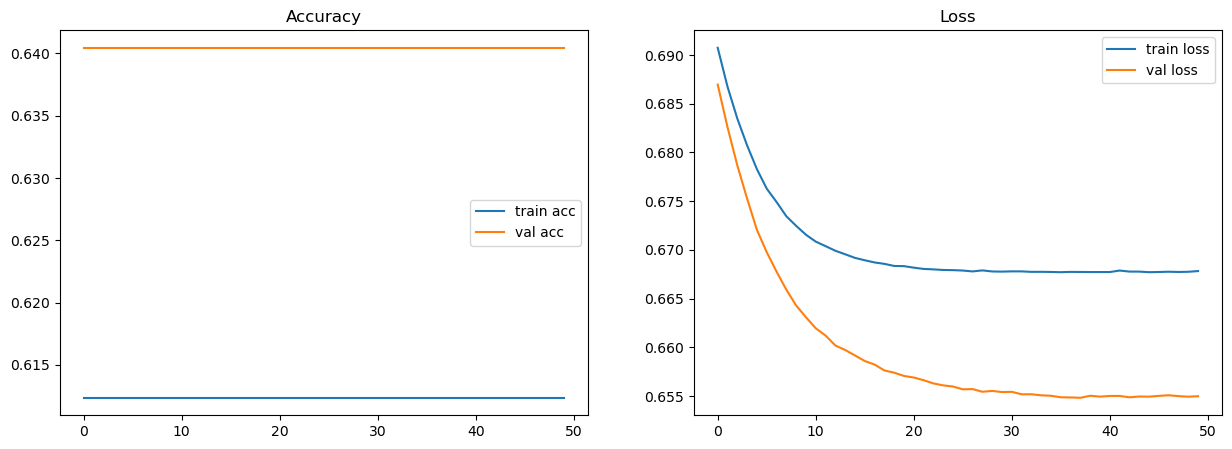

In [11]:
history = history.history 
plt.figure(figsize=(15,5)) 
plt.subplot(121) 
plt.title("Accuracy") 
plt.plot(history["accuracy"],label="train acc") 
plt.plot(history["val_accuracy"],label="val acc") 
plt.legend() 
plt.subplot(122) 
plt.title("Loss") 
plt.plot(history["loss"],label="train loss") 
plt.plot(history["val_loss"],label="val loss") 
plt.legend() 
plt.show() 

In [12]:
loss ,accuracy = model.evaluate(test_ds)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6222 - loss: 0.6632


In [13]:
print("test loss :",loss) 
print("test accuracy :",accuracy) 

test loss : 0.6632218956947327
test accuracy : 0.6222222447395325
